## Import Libraries

In [45]:
from xgboost import XGBRegressor
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Load Data

In [8]:
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train = train.set_index('Id')
test = test.set_index('Id')
train.head(10)


Train shape: (1460, 81)
Test shape: (1459, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


In [10]:
train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [11]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print(missing_train)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [12]:
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print(missing_test)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageQual        78
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
Exterior1st        1
Exterior2nd        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1
dtype: int64


## Cleaning Data

In [13]:
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'MasVnrType', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2'
]

for df in [train, test]:
    for col in none_cols:
        df[col] = df[col].fillna('None')

In [14]:
zero_cols = [
    'MasVnrArea',
    'BsmtFullBath', 'BsmtHalfBath',
    'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF',
    'GarageCars', 'GarageArea'
]

for df in [train, test]:
    for col in zero_cols:
        df[col] = df[col].fillna(0)

In [18]:
train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False)
test.isnull().sum()[test.isnull().sum() > 0].sort_values(ascending=False)


LotFrontage    227
GarageYrBlt     78
MSZoning         4
Functional       2
Utilities        2
Exterior2nd      1
Exterior1st      1
KitchenQual      1
SaleType         1
dtype: int64

In [22]:
for df in [train, test]:
    df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median())
    )
for df in [train, test]:
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
    
for df in [train, test]:
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)



In [23]:
mode_cols = [
    "MSZoning",
    "Functional",
    "Utilities",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "SaleType",
    "Electrical"
]

for col in mode_cols:
    if col in train.columns:
        train[col] = train[col].fillna(train[col].mode()[0])

    if col in test.columns:
        test[col] = test[col].fillna(train[col].mode()[0])

In [24]:
print("Train missing:", train.isnull().sum().sum())
print("Test missing:", test.isnull().sum().sum())

Train missing: 0
Test missing: 0


In [62]:
outliers = train[
    (train["GrLivArea"] > 4000) &
    (train["SalePrice"] < 300000)
]

outliers[["GrLivArea", "SalePrice"]]

,GrLivArea,SalePrice
Id,,
524,4676,184750
1299,5642,160000


## Feature Engineering

In [69]:
for df in [train, test]:
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    df["TotalBathrooms"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]

    df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
        + df["WoodDeckSF"]
    )

    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    
# Extra feature engineering
for df in [train, test]:
    df["TotalOutdoorSF"] = (
        df["WoodDeckSF"]
        + df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
        + df["PoolArea"]
    )

    df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
    df["IsNew"] = (df["YearBuilt"] == df["YrSold"]).astype(int)

In [70]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

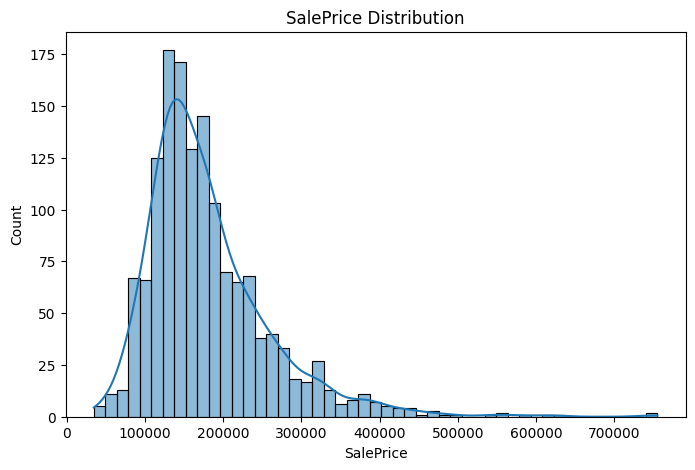

Skewness: 1.8828757597682129


In [71]:
plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

print("Skewness:", train["SalePrice"].skew())

In [72]:
X = train.drop("SalePrice", axis=1)
y = np.log1p(train["SalePrice"])

all_data = pd.concat([X, test])
all_data = pd.get_dummies(all_data)

X = all_data.iloc[:len(train)]
X_test = all_data.iloc[len(train):]

print(X.shape)
print(X_test.shape)

(1460, 316)
(1459, 316)


## baseline models
### 1. Ridge Regression

In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=10)

scores = cross_val_score(
    ridge,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rmse = -scores.mean()

print("CV RMSE:", rmse)

CV RMSE: 0.13626897487406814


### 2. Gradient Boosting

In [42]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

gbr = GradientBoostingRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=4,
    max_features="sqrt",
    min_samples_leaf=15,
    min_samples_split=10,
    loss="huber",
    random_state=42
)

scores = cross_val_score(
    gbr,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

print("Gradient Boosting CV RMSE:", -scores.mean())

Gradient Boosting CV RMSE: 0.12235702227525813


In [66]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.001,
    reg_lambda=1,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

print("XGBoost CV RMSE:", -scores.mean())

XGBoost CV RMSE: 0.11889521102269285


In [67]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

lgbm = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=20,
    max_depth=5,
    min_child_samples=20,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=4,
    verbose=-1
)

scores = cross_val_score(
    lgbm,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=1
)

print("LightGBM RMSE:", -scores.mean())

LightGBM RMSE: 0.12610548249798473


In [81]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

xgb_v2 = XGBRegressor(
    n_estimators=2200,
    learning_rate=0.025,
    max_depth=3,
    min_child_weight=1.5,
    subsample=0.65,
    colsample_bytree=0.65,
    reg_alpha=0.15,
    reg_lambda=0.9,
    gamma=0.01,
    tree_method="hist",
    n_jobs=4,
    random_state=42
)

scores = cross_val_score(
    xgb_v2,
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=1
)

print("XGBoost V2 RMSE:", -scores.mean())

XGBoost V2 RMSE: 0.11784871893247031


In [82]:
xgb_v2.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.65
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [83]:
pred_log = xgb_v2.predict(X_test)

# y was created using np.log1p(), so reverse it with expm1()
pred_price = np.expm1(pred_log)

In [84]:
submission = pd.DataFrame({
    "Id": test.index,
    "SalePrice": pred_price
})

submission.to_csv("submission_xgb_v2.csv", index=False)

submission.head()

,Id,SalePrice
0,1461,122039.664062
1,1462,158838.390625
2,1463,183425.578125
3,1464,196729.015625
4,1465,180526.203125


In [85]:
print(os.path.abspath("submission_xgb_v2.csv"))

C:\Users\DFIT\Kaggle Projects\House_Price_Prediction\submission_xgb_v2.csv
